# EDA 2 - Diagnóstico da CNN 

In [34]:
from __future__ import annotations

import json
import sys
from pathlib import Path


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("could not locate project root (no pyproject.toml found upward)")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(PROJECT_ROOT))

EDA_DIR = PROJECT_ROOT / "reports" / "eda_2"
RUN_DIR = PROJECT_ROOT / "multirun" / "cnn_test1"
MANIFEST_PATH = PROJECT_ROOT / "data" / "processed" / "manifest.json"

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"RUN_DIR      = {RUN_DIR} (existe: {RUN_DIR.exists()})")


PROJECT_ROOT = C:\Users\julia\Documents\projects\IC-F\qtl-breast-cancer
RUN_DIR      = C:\Users\julia\Documents\projects\IC-F\qtl-breast-cancer\multirun\cnn_test1 (existe: True)


In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "font.size": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})
PALETTE = {
    "dataset": {"small": "#f163a8", "medium": "#a53faa", "big": "#66f1c2"},
    "label": {"benign": "#2a78d6", "malignant": "#e34948"},
}
DATASET_ORDER = ["small", "medium", "big"]
LABEL_ORDER = ["benign", "malignant"]


### Carregando os resultados teste 1

In [36]:
def load_runs(run_dir: Path) -> pd.DataFrame:
    rows = []
    for f in run_dir.rglob("metrics.json"):
        r = json.loads(f.read_text(encoding="utf-8"))
        for target, m in r["targets"].items():
            rows.append({
                "source": r["source"],
                "seed": r["seed"],
                "target": target,
                "commit": r["commit"][:8],
                "dirty": r["dirty"],
                "best_epoch": r["best_epoch"],
                "best_val_auc": r["best_val_auc"],
                **m,
            })
    return pd.DataFrame(rows)


df = load_runs(RUN_DIR)
df.to_csv(EDA_DIR / "results_tidy.csv", index=False)
df.head()


,source,seed,target,commit,dirty,best_epoch,best_val_auc,acc,macro_f1,recall_malignant,roc_auc,pr_auc,prevalence
0,small,0,small,9541eda2,False,14,0.831306,0.782609,0.725373,0.483871,0.804865,0.707541,0.336957
1,small,0,medium,9541eda2,False,14,0.831306,0.704626,0.624192,0.373626,0.701851,0.499467,0.323843
2,small,0,big,9541eda2,False,14,0.831306,0.523810,0.513889,0.304762,0.641534,0.749394,0.625000
3,small,1,small,9541eda2,False,25,0.819143,0.771739,0.721734,0.516129,0.840825,0.772173,0.336957
4,small,1,medium,9541eda2,False,25,0.819143,0.718861,0.648110,0.417582,0.680162,0.502800,0.323843


### Testando Cross-Domain

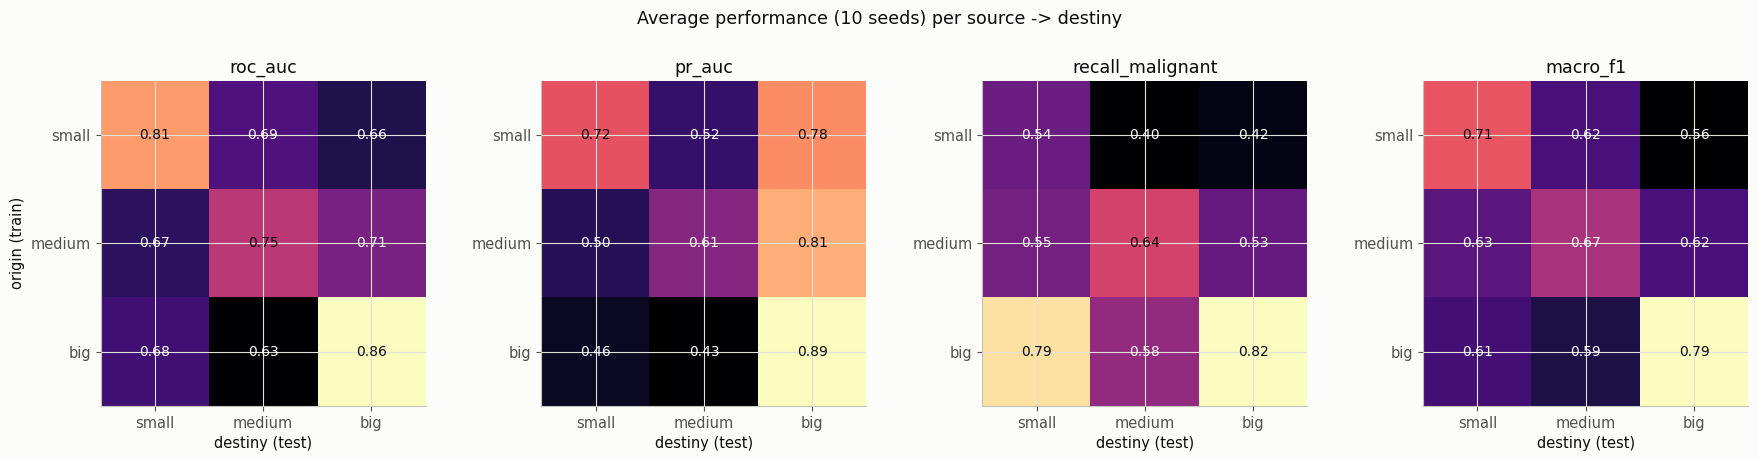

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.3))
metrics_of_interest = ["roc_auc", "pr_auc", "recall_malignant", "macro_f1"]

for ax, metric in zip(axes, metrics_of_interest):
    mean_pivot = (
        df.groupby(["source", "target"])[metric].mean()
        .unstack()
        .reindex(index=DATASET_ORDER, columns=DATASET_ORDER)
    )
    im = ax.imshow(mean_pivot.values, cmap="magma", vmin=mean_pivot.values.min(), vmax=mean_pivot.values.max())
    ax.set_xticks(range(len(DATASET_ORDER)))
    ax.set_xticklabels(DATASET_ORDER)
    ax.set_yticks(range(len(DATASET_ORDER)))
    ax.set_yticklabels(DATASET_ORDER)
    ax.set_xlabel("destiny (test)")
    if ax is axes[0]:
        ax.set_ylabel("origin (train)")
    ax.set_title(metric)

    vmid = (mean_pivot.values.min() + mean_pivot.values.max()) / 2
    for i in range(len(DATASET_ORDER)):
        for j in range(len(DATASET_ORDER)):
            val = mean_pivot.values[i, j]
            color = "#0b0b0b" if val > vmid else "#fcfcfb"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=10)

fig.suptitle("Average performance (10 seeds) per source -> destiny", y=1.03)
fig.tight_layout()
plt.show()


C:\Users\julia\AppData\Local\Temp\ipykernel_7164\35744658.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


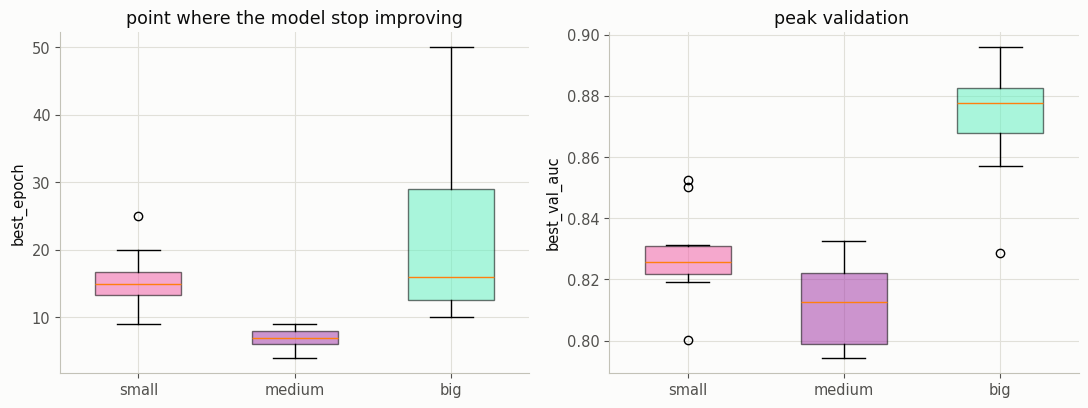

best_epoch                 best_val_auc                     
             mean     std min max         mean    std    min    max
source                                                             
big          21.5  13.235  10  50        0.873  0.019  0.828  0.896
medium        6.8   1.549   4   9        0.812  0.015  0.794  0.833
small        15.5   4.528   9  25        0.828  0.015  0.800  0.852

In [5]:
stability = df.drop_duplicates(subset=["source", "seed"])[["source", "seed", "best_epoch", "best_val_auc"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

data_epoch = [stability.loc[stability["source"] == ds, "best_epoch"].to_numpy() for ds in DATASET_ORDER]
bp = axes[0].boxplot(data_epoch, tick_labels=DATASET_ORDER, patch_artist=True, widths=0.55)
for patch, ds in zip(bp["boxes"], DATASET_ORDER):
    patch.set_facecolor(PALETTE["dataset"][ds])
    patch.set_alpha(0.55)
axes[0].set_ylabel("best_epoch")
axes[0].set_title("point where the model stop improving")
axes[0].legend()

data_auc = [stability.loc[stability["source"] == ds, "best_val_auc"].to_numpy() for ds in DATASET_ORDER]
bp2 = axes[1].boxplot(data_auc, tick_labels=DATASET_ORDER, patch_artist=True, widths=0.55)
for patch, ds in zip(bp2["boxes"], DATASET_ORDER):
    patch.set_facecolor(PALETTE["dataset"][ds])
    patch.set_alpha(0.55)
axes[1].set_ylabel("best_val_auc")
axes[1].set_title("peak validation ")

fig.tight_layout()
plt.show()

display(stability.groupby("source")[["best_epoch", "best_val_auc"]].agg(["mean", "std", "min", "max"]).round(3))


split,test,train,val
dataset,,,
small,33.7,33.5,33.7
medium,32.4,32.4,32.4
big,62.5,62.5,62.5


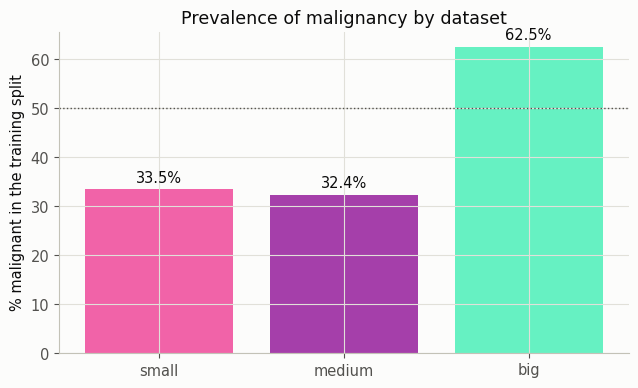

In [38]:
with MANIFEST_PATH.open(encoding="utf-8") as f:
    manifest = json.load(f)

samples = manifest["samples"]
rows = []
for ds in DATASET_ORDER:
    for split in ["train", "val", "test"]:
        subset = [s for s in samples if s["dataset"] == ds and s["split"] == split]
        n_malignant = sum(1 for s in subset if s["label"] == "malignant")
        rows.append({
            "dataset": ds,
            "split": split,
            "n": len(subset),
            "pct_malignant": round(100 * n_malignant / len(subset), 1) if subset else float("nan"),
        })

prevalence_df = pd.DataFrame(rows)
display(prevalence_df.pivot(index="dataset", columns="split", values="pct_malignant").reindex(DATASET_ORDER))

fig, ax = plt.subplots(figsize=(6.5, 4))
train_prev = prevalence_df[prevalence_df["split"] == "train"].set_index("dataset").reindex(DATASET_ORDER)
bars = ax.bar(DATASET_ORDER, train_prev["pct_malignant"], color=[PALETTE["dataset"][d] for d in DATASET_ORDER])
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.axhline(50, color="#52514e", linestyle=":", linewidth=1)
ax.set_ylabel("% malignant in the training split")
ax.set_title("Prevalence of malignancy by dataset")
fig.tight_layout()
plt.show()


## Análise de erros por imagem

In [ ]:
def test_samples(domain: str) -> list[dict]:
    return [s for s in samples if s["dataset"] == domain and s["split"] == "test"]


test_lookup = {d: test_samples(d) for d in DATASET_ORDER}

THRESHOLD = 0.5

def load_predictions(source: str, target: str) -> np.ndarray:
    arrs = []
    for seed in range(10):
        p = RUN_DIR / f"src_{source}" / f"seed{seed}" / f"preds_{target}.npz"
        arrs.append(np.load(p)["probs"])
    return np.stack(arrs)


rows = []
for source in DATASET_ORDER:
    for target in DATASET_ORDER:
        probs_stack = load_predictions(source, target)
        samp = test_lookup[target]
        labels = np.array([s["label_id"] for s in samp])
        preds_stack = (probs_stack >= THRESHOLD).astype(int)
        wrong = preds_stack != labels[None, :]

        for i, s in enumerate(samp):
            rows.append({
                "source": source,
                "target": target,
                "sample_id": s["sample_id"],
                "label": s["label"],
                "label_id": s["label_id"],
                "mean_prob": probs_stack[:, i].mean(),
                "std_prob": probs_stack[:, i].std(),
                "error_rate": wrong[:, i].mean(),
            })

error_df = pd.DataFrame(rows)
error_df.to_csv(EDA_DIR / "per_sample_errors.csv", index=False)
error_df.head()


,source,target,sample_id,label,label_id,mean_prob,std_prob,error_rate
0,small,small,small-benign-0002,benign,0,0.023474,0.023972,0.0
1,small,small,small-benign-0005,benign,0,0.006282,0.010346,0.0
2,small,small,small-benign-0006,benign,0,0.109816,0.193786,0.1
3,small,small,small-benign-0015,benign,0,0.013686,0.026845,0.0
4,small,small,small-benign-0024,benign,0,0.328182,0.279335,0.3


In [40]:
features_df = pd.read_csv(PROJECT_ROOT / "reports" / "eda_1" / "tidy_manifest_eda.csv")
feature_cols = [
    "sample_id", "image_path", "has_mask", "institution",
    "roi_mean", "roi_std", "snr_db", "speckle_index", "roi_entropy_bits",
    "aspect_ratio", "width", "height",
]
merged = error_df.merge(features_df[feature_cols], on="sample_id", how="left")


In [42]:
in_domain = merged[merged["source"] == merged["target"]].copy()

def consistency_counts(s: pd.Series) -> pd.Series:
    return pd.Series({
        "wrong": int((s == 1.0).sum()),
        "right": int((s == 0.0).sum()),
        "n": len(s),
    })


consistency = in_domain.groupby(["source", "label"])["error_rate"].apply(consistency_counts).unstack()
consistency["%_wrong"] = (100 * consistency["wrong"] / consistency["n"]).round(1)
display(consistency.reindex(DATASET_ORDER, level="source"))


wrong  right    n  %_wrong
source label                                
small  benign         0     36   61      0.0
       malignant      7     10   31     22.6
medium benign        14     94  190      7.4
       malignant     13     35   91     14.3
big    benign         9     66  126      7.1
       malignant      5    121  210      2.4

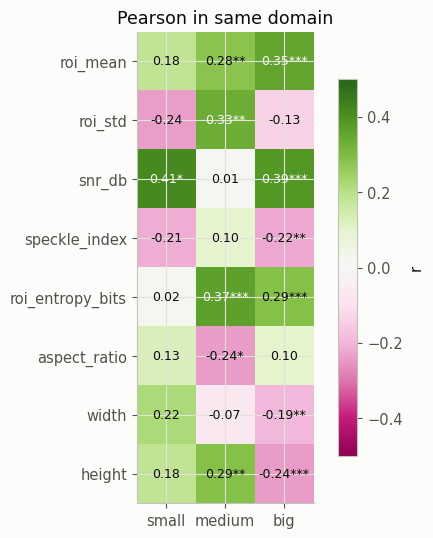

In [48]:
from scipy.stats import pearsonr

pearson_matrix = pd.DataFrame(index=feat_numeric, columns=DATASET_ORDER, dtype=float)
pearson_pvals = pd.DataFrame(index=feat_numeric, columns=DATASET_ORDER, dtype=float)

for source in DATASET_ORDER:
    sub = in_domain[(in_domain["source"] == source) & (in_domain["label"] == "malignant")]
    sub = sub.merge(features_df[feature_cols], on="sample_id", how="left", suffixes=("", "_dup"))
    for feat in feat_numeric:
        valid = sub[[feat, "error_rate"]].dropna()
        r, p = pearsonr(valid[feat], valid["error_rate"])
        pearson_matrix.loc[feat, source] = r
        pearson_pvals.loc[feat, source] = p

fig, ax = plt.subplots(figsize=(5.5, 5.5))
im = ax.imshow(pearson_matrix.values, cmap="PiYG", vmin=-0.5, vmax=0.5)
ax.set_xticks(range(len(DATASET_ORDER)))
ax.set_xticklabels(DATASET_ORDER)
ax.set_yticks(range(len(feat_numeric)))
ax.set_yticklabels(feat_numeric)
ax.set_title("Pearson in same domain")
fig.colorbar(im, ax=ax, label="r", shrink=0.8)

for i, feat in enumerate(feat_numeric):
    for j, source in enumerate(DATASET_ORDER):
        r = pearson_matrix.loc[feat, source]
        p = pearson_pvals.loc[feat, source]
        stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        color = "#fcfcfb" if abs(r) > 0.3 else "#0b0b0b"
        ax.text(j, i, f"{r:.2f}{stars}", ha="center", va="center", color=color, fontsize=9)

fig.tight_layout()
plt.show()

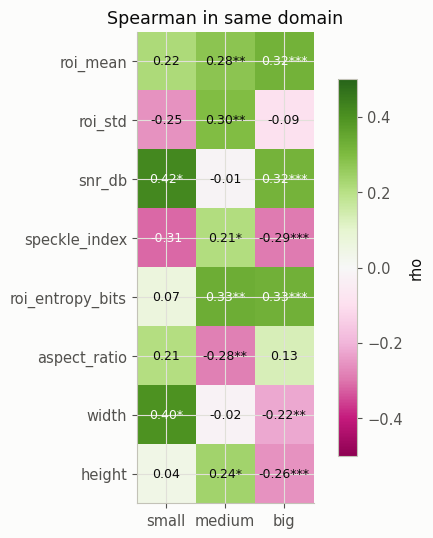

In [46]:
in_domain = merged[merged["source"] == merged["target"]].copy()

from scipy.stats import spearmanr

feat_numeric = ["roi_mean", "roi_std", "snr_db", "speckle_index", "roi_entropy_bits", "aspect_ratio", "width", "height"]

corr_matrix = pd.DataFrame(index=feat_numeric, columns=DATASET_ORDER, dtype=float)
pval_matrix = pd.DataFrame(index=feat_numeric, columns=DATASET_ORDER, dtype=float)

for source in DATASET_ORDER:
    sub = in_domain[(in_domain["source"] == source) & (in_domain["label"] == "malignant")]
    sub = sub.merge(features_df[feature_cols], on="sample_id", how="left", suffixes=("", "_dup"))
    for feat in feat_numeric:
        valid = sub[[feat, "error_rate"]].dropna()
        rho, p = spearmanr(valid[feat], valid["error_rate"])
        corr_matrix.loc[feat, source] = rho
        pval_matrix.loc[feat, source] = p

fig, ax = plt.subplots(figsize=(5.5, 5.5))
im = ax.imshow(corr_matrix.values, cmap="PiYG", vmin=-0.5, vmax=0.5)
ax.set_xticks(range(len(DATASET_ORDER)))
ax.set_xticklabels(DATASET_ORDER)
ax.set_yticks(range(len(feat_numeric)))
ax.set_yticklabels(feat_numeric)
ax.set_title("Spearman in same domain")
fig.colorbar(im, ax=ax, label="rho", shrink=0.8)

for i, feat in enumerate(feat_numeric):
    for j, source in enumerate(DATASET_ORDER):
        rho = corr_matrix.loc[feat, source]
        p = pval_matrix.loc[feat, source]
        stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        color = "#fcfcfb" if abs(rho) > 0.3 else "#0b0b0b"
        ax.text(j, i, f"{rho:.2f}{stars}", ha="center", va="center", color=color, fontsize=9)

fig.tight_layout()
plt.show()


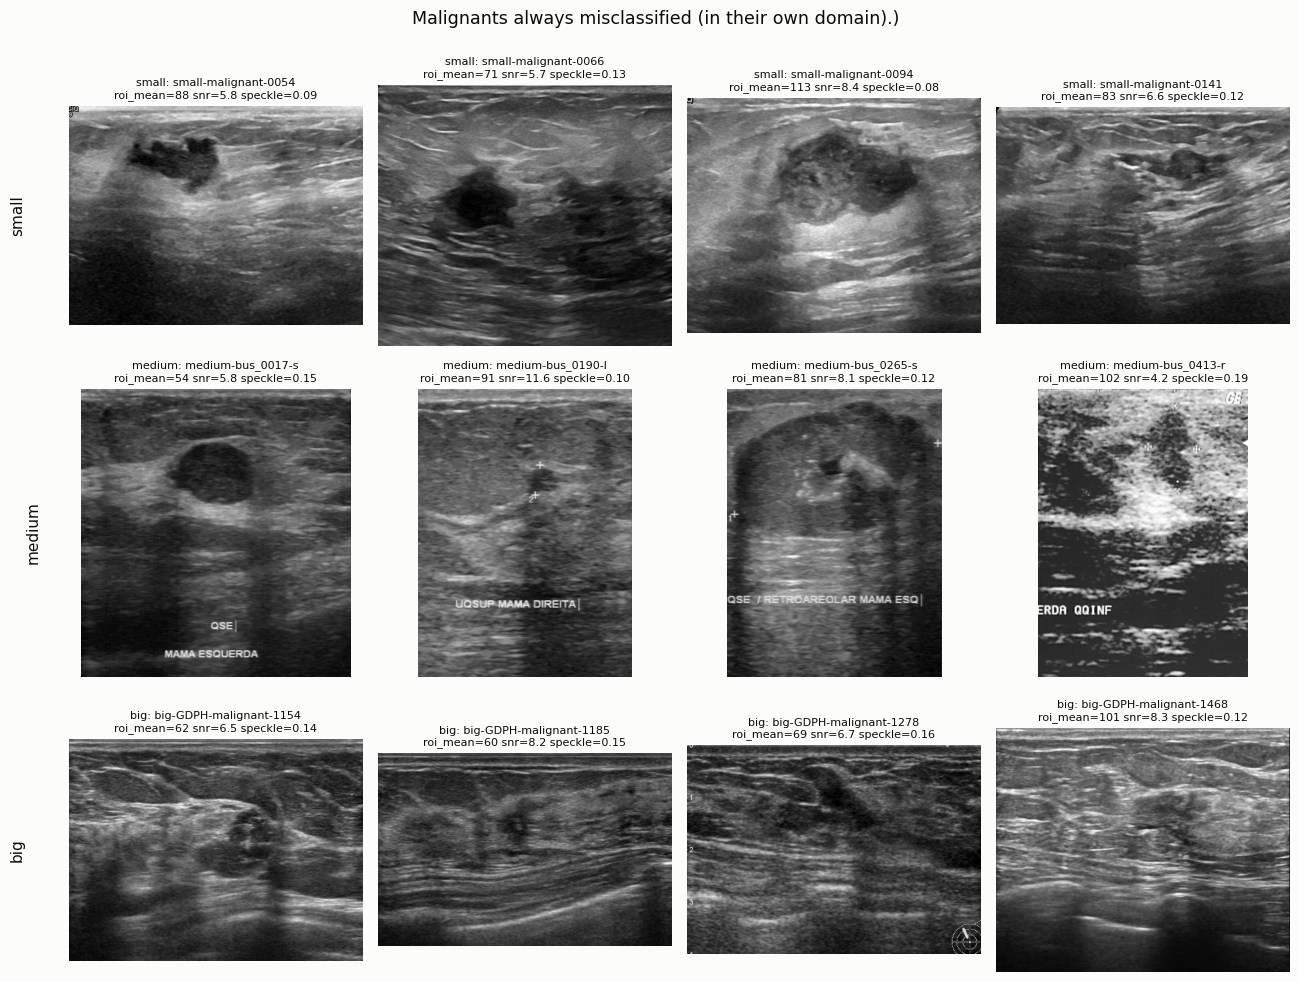

In [47]:
from PIL import Image

always_wrong_malignant = in_domain[
    (in_domain["label"] == "malignant") & (in_domain["error_rate"] == 1.0)
].merge(features_df[feature_cols], on="sample_id", how="left", suffixes=("", "_dup"))

fig, axes = plt.subplots(3, 4, figsize=(13, 10))
for row, source in enumerate(DATASET_ORDER):
    examples = always_wrong_malignant[always_wrong_malignant["source"] == source].head(4)
    for col in range(4):
        ax = axes[row, col]
        ax.axis("off")
        if col < len(examples):
            ex = examples.iloc[col]
            img = Image.open(PROJECT_ROOT / ex["image_path"]).convert("L")
            ax.imshow(img, cmap="gray")
            ax.set_title(
                f"{source}: {ex['sample_id']}\nroi_mean={ex['roi_mean']:.0f} snr={ex['snr_db']:.1f} speckle={ex['speckle_index']:.2f}",
                fontsize=8,
            )
        if col == 0:
            ax.text(-0.15, 0.5, source, transform=ax.transAxes, fontsize=11,
                     va="center", ha="right", rotation=90)

fig.suptitle("Malignants always misclassified (in their own domain).)", y=1.0)
fig.tight_layout()
plt.show()


In [49]:
text_feats = features_df[["sample_id", "top_band_text_candidate", "bottom_band_text_candidate"]].copy()
text_feats["has_text"] = text_feats["top_band_text_candidate"] | text_feats["bottom_band_text_candidate"]

in_domain_text = in_domain.merge(text_feats[["sample_id", "has_text"]], on="sample_id", how="left")
text_check = (
    in_domain_text[in_domain_text["label"] == "malignant"]
    .groupby(["source", "has_text"])["error_rate"]
    .agg(["mean", "count"])
    .round(3)
)
display(text_check)


mean  count
source has_text              
big    False     0.157     53
       True      0.189    157
medium False     0.511     38
       True      0.251     53
small  False     1.000      1
       True      0.447     30